In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# работает через direct_url
standart_url = 'https://drive.google.com/file/d/1mvlvKNwWJjOJfVGL61ijip7RKIGszIxq/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1mvlvKNwWJjOJfVGL61ijip7RKIGszIxq'

voice_data = pd.read_csv(direct_url)

In [4]:
voice_data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [5]:
voice_data.shape

(3168, 21)

In [6]:
voice_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

все признаки, за исключением целевого, кодируются числовым форматом. Типизация целевой переменной не имеет значения для моделей машинного обучения в библиотеке sklearn, поэтому кодирование категориальных признаков нам не потребуется.

In [10]:
voice_data.isnull().sum().sum()

0

→ При желании вы можете провести разведывательный анализ и изучить взаимосвязи между признаками, описывающими голос на аудиозаписи, и целевой переменной, чтобы предварительно определить наиболее значимые признаки и их влияние.

Мы же пропустим этот шаг и перейдём к формированию обучающей и тестовой выборок. Разделим датасет на две части в соотношении 80/20:

In [ ]:
# делим выборку на фичи и таргет
y = voice_data['label']
X = voice_data.drop(columns='label')

# Формируем обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

**Задание 7.1**

Начнём с решающего пня.

Создайте модель дерева решений максимальной глубины 1. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

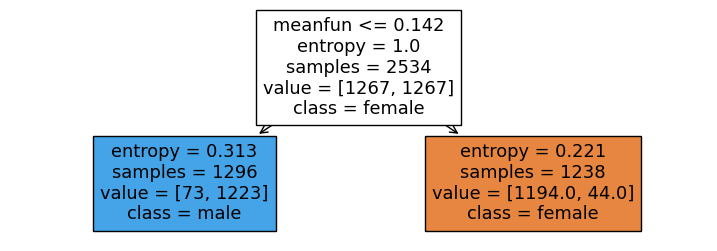

In [44]:
dt = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='entropy',
    # min_samples_leaf=3,
    max_depth=1,
    # max_leaf_nodes=3,
    # min_samples_split=6,
    # min_samples_leaf=3,
)
dt.fit(X_train, y_train)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=dt.classes_, 
    filled=True, 
    impurity=True
);

In [35]:
1296/2534*100

51.14443567482242

In [38]:
model = dt
# 3. Предсказания на обеих выборках
# Предсказание на обучающей выборке (X_train)
y_train_pred = model.predict(X_train)

# Предсказание на тестовой выборке (X_test)
y_test_pred = model.predict(X_test)

# 4. Расчет метрики Accuracy
# Расчет accuracy для обучающей выборки
train_accuracy = accuracy_score(y_train, y_train_pred)

# Расчет accuracy для тестовой выборки
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy на обучающей выборке: {train_accuracy:.3f}")
print(f"Accuracy на тестовой выборке: {test_accuracy:.3f}")

Accuracy на обучающей выборке: 0.954
Accuracy на тестовой выборке: 0.956


**Задание 7.2**

Увеличим глубину дерева.

Создайте дерево решений с максимальной глубиной 2. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

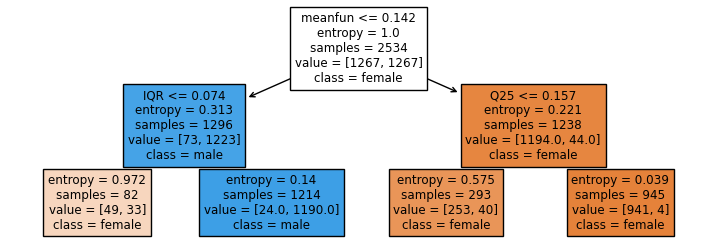

In [46]:
dt = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='entropy',
    # min_samples_leaf=3,
    max_depth=2,
    # max_leaf_nodes=3,
    # min_samples_split=6,
    # min_samples_leaf=3,
)
dt.fit(X_train, y_train)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=dt.classes_, 
    filled=True, 
    impurity=True
);

In [47]:
model = dt
# 3. Предсказания на обеих выборках
# Предсказание на обучающей выборке (X_train)
y_train_pred = model.predict(X_train)

# Предсказание на тестовой выборке (X_test)
y_test_pred = model.predict(X_test)

# 4. Расчет метрики Accuracy
# Расчет accuracy для обучающей выборки
train_accuracy = accuracy_score(y_train, y_train_pred)

# Расчет accuracy для тестовой выборки
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy на обучающей выборке: {train_accuracy:.3f}")
print(f"Accuracy на тестовой выборке: {test_accuracy:.3f}")

Accuracy на обучающей выборке: 0.960
Accuracy на тестовой выборке: 0.962


**Задание 7.3**

Давайте дадим дереву решений полную свободу.

Создайте дерево решений, не ограничивая его максимальную глубину. В качестве критерия информативности используйте энтропию Шеннона.

В качестве значения параметра random_state возьмите 0.

Обучите модель на тренировочной выборке.

In [ ]:
dt = tree.DecisionTreeClassifier(
    random_state=0,
    criterion='entropy',
    # min_samples_leaf=3,
    # max_depth=2,
    # max_leaf_nodes=3,
    # min_samples_split=6,
    # min_samples_leaf=3,
)
dt.fit(X_train, y_train)

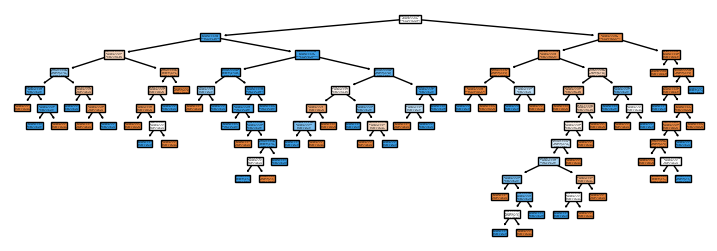

In [51]:
fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=dt.classes_, 
    filled=True, 
    impurity=True
);

1. Чему равна глубина полученного дерева решения? Напомним, что глубину дерева можно узнать с помощью метода get_depth().

In [52]:
dt.get_depth()

12

2. Чему равно количество листьев в полученном дереве решений? Напомним, что количество листьев можно узнать с помощью метода get_n_leaves().

In [53]:
dt.get_n_leaves()

54

In [54]:
model = dt
# 3. Предсказания на обеих выборках
# Предсказание на обучающей выборке (X_train)
y_train_pred = model.predict(X_train)

# Предсказание на тестовой выборке (X_test)
y_test_pred = model.predict(X_test)

# 4. Расчет метрики Accuracy
# Расчет accuracy для обучающей выборки
train_accuracy = accuracy_score(y_train, y_train_pred)

# Расчет accuracy для тестовой выборки
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy на обучающей выборке: {train_accuracy:.3f}")
print(f"Accuracy на тестовой выборке: {test_accuracy:.3f}")

Accuracy на обучающей выборке: 1.000
Accuracy на тестовой выборке: 0.973


**Задание 7.4**

Давайте попробуем найти оптимальные внешние параметры модели дерева решений для поставленной задачи. Воспользуемся классическим методом подбора гиперпараметров — перебором на сетке с кросс-валидацией (Grid SearchCV).

Задана следующая сетка параметров:

In [56]:
# Задаём сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'], # критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], # максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10], # минимальное количество объектов, необходимое для сплита
}

В качестве кросс-валидатора будем использовать k-fold-валидатор со стратификацией (StratifiedKFold):

In [57]:
# Задаём метод кросс-валидации
cv = model_selection.StratifiedKFold(n_splits=5)

С помощью Grid SearchCV из модуля model_selection библиотеки sklearn переберите гиперпараметры дерева решений из приведённой сетки на обучающей выборке и найдите оптимальные. Параметр random_state для дерева решений установите равным 0. В качестве метрики качества (параметр scoring) используйте accuracy.

In [60]:
dtree = dt
# 4. Инициализация GridSearchCV
grid_search = GridSearchCV(
    estimator=dtree,      # Модель для обучения
    param_grid=param_grid, # Сетка параметров
    cv=cv,                 # Количество фолдов кросс-валидации
    scoring='accuracy',   # Метрика качества (например, точность)
    verbose=1,            # Уровень детализации вывода (1 - по умолчанию)
    n_jobs=-1             # Использование всех доступных ядер процессора для параллельных вычислений
)

# 5. Запуск поиска по сетке (обучение модели)
grid_search.fit(X_train, y_train)

# 6. Получение наилучших результатов
print(f"Лучшая оценка (accuracy) по кросс-валидации: {grid_search.best_score_:.4f}")
print(f"Лучшие гиперпараметры: {grid_search.best_params_}")

# 7. Использование лучшей модели
# Лучшая модель автоматически сохраняется в best_estimator_
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 56 candidates, totalling 280 fits
Лучшая оценка (accuracy) по кросс-валидации: 0.9657
Лучшие гиперпараметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}


4. С помощью наилучшей модели сделайте предсказание для обучающей и тестовой выборок. Рассчитайте значение метрики accuracy на каждой из выборок. Ответы округлите до трёх знаков после точки-разделителя.

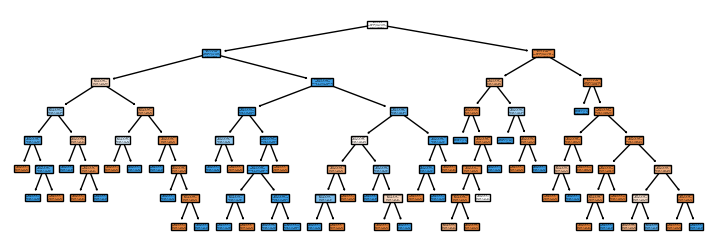

In [63]:
dt = tree.DecisionTreeClassifier(
    random_state=0,
    criterion='gini',
    # min_samples_leaf=3,
    max_depth=7,
    # max_leaf_nodes=3,
    min_samples_split=3,
    # min_samples_leaf=3,
)
dt.fit(X_train, y_train)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=dt.classes_, 
    filled=True, 
    impurity=True
);

In [64]:
model = dt
# 3. Предсказания на обеих выборках
# Предсказание на обучающей выборке (X_train)
y_train_pred = model.predict(X_train)

# Предсказание на тестовой выборке (X_test)
y_test_pred = model.predict(X_test)

# 4. Расчет метрики Accuracy
# Расчет accuracy для обучающей выборки
train_accuracy = accuracy_score(y_train, y_train_pred)

# Расчет accuracy для тестовой выборки
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy на обучающей выборке: {train_accuracy:.3f}")
print(f"Accuracy на тестовой выборке: {test_accuracy:.3f}")

Accuracy на обучающей выборке: 0.996
Accuracy на тестовой выборке: 0.970


**Задание 7.5**

Для оптимального дерева решений, построенного в задании 7.4, найдите важность каждого из факторов. Визуализируйте её в виде столбчатой диаграммы.

Выделите топ-3 наиболее важных факторов, участвующих в построении дерева решений:

In [67]:
dt.feature_importances_

array([0.00257071, 0.00412021, 0.00324731, 0.00143184, 0.00361359,
       0.05681024, 0.00419621, 0.00654448, 0.00091911, 0.01800429,
       0.0060468 , 0.00598505, 0.86134736, 0.01415259, 0.        ,
       0.00119966, 0.00153412, 0.        , 0.00688824, 0.0013882 ])

In [69]:
dt

DecisionTreeClassifier(max_depth=7, min_samples_split=3, random_state=0)

In [74]:
feature_names = X.columns
feature_names

Index(['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt',
       'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx'],
      dtype='object')

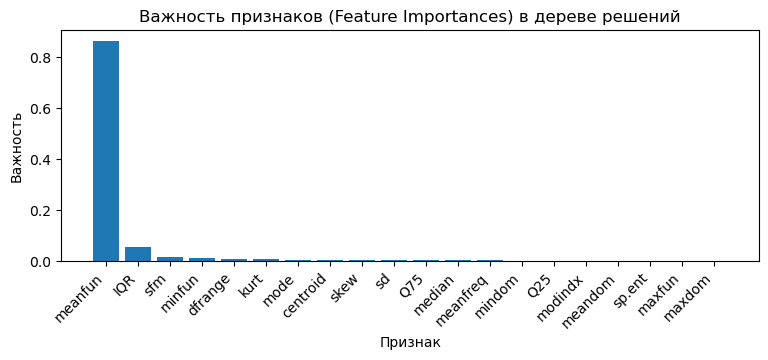

Отсортированная важность признаков:
     feature  importance
12   meanfun    0.861347
5        IQR    0.056810
9        sfm    0.018004
13    minfun    0.014153
18   dfrange    0.006888
7       kurt    0.006544
10      mode    0.006047
11  centroid    0.005985
6       skew    0.004196
1         sd    0.004120
4        Q75    0.003614
2     median    0.003247
0   meanfreq    0.002571
16    mindom    0.001534
3        Q25    0.001432
19   modindx    0.001388
15   meandom    0.001200
8     sp.ent    0.000919
14    maxfun    0.000000
17    maxdom    0.000000


In [76]:
model = dt

# 3. Получение важности признаков
# Атрибут feature_importances_ возвращает массив значений важности для каждого признака.
importances = model.feature_importances_

# 4. Визуализация важности признаков в виде столбчатой диаграммы
# Создание DataFrame для удобства сортировки и построения графика.
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Сортировка по важности в порядке убывания
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Построение столбчатой диаграммы
plt.figure(figsize=(9, 3))
plt.bar(x=feature_importance_df['feature'], height=feature_importance_df['importance'])
plt.title('Важность признаков (Feature Importances) в дереве решений')
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right') # Поворот названий признаков для лучшей читаемости
plt.show()

# Дополнительно: вывод отсортированных значений
print("Отсортированная важность признаков:")
print(feature_importance_df)